# Análisis y Predicción de Homicidios en Accidentes de Tránsito

# 1. Configuración del entorno - Importamos las bibliotecas necesarias

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Cargamos los Datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
ruta_archivo = '/Homicidios_accidente_de_tr_nsito_Polic_a_Nacional_20250212.csv'

df = pd.read_csv(ruta_archivo)

#3. Exploración inicial de los datos

In [6]:
df.head()


,DEPARTAMENTO,MUNICIPIO,CODIGO DANE,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARÍO,DESCRIPCIÓN CONDUCTA,CANTIDAD
0,ANTIOQUIA,LA CEJA,5376000.0,MOTO,1/01/2010,MASCULINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0
1,ATLÁNTICO,BARRANQUILLA (CT),8001000.0,MOTO,1/01/2010,FEMENINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0
2,ATLÁNTICO,LURUACO,8421000.0,MOTO,1/01/2010,MASCULINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0
3,CAQUETÁ,PUERTO RICO,18592000.0,MOTO,1/01/2010,MASCULINO,ADOLESCENTES,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0
4,CASANARE,AGUAZUL,85010000.0,MOTO,1/01/2010,MASCULINO,ADULTOS,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0


In [7]:
# Información general del dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84294 entries, 0 to 84293
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DEPARTAMENTO          82354 non-null  object 
 1   MUNICIPIO             82354 non-null  object 
 2   CODIGO DANE           82354 non-null  float64
 3   ARMAS MEDIOS          82354 non-null  object 
 4   FECHA HECHO           82354 non-null  object 
 5   GENERO                82354 non-null  object 
 6   GRUPO ETARÍO          82354 non-null  object 
 7   DESCRIPCIÓN CONDUCTA  84294 non-null  object 
 8   CANTIDAD              82354 non-null  float64
dtypes: float64(2), object(7)
memory usage: 5.8+ MB


In [8]:
# Revisar valores nulos
df.isnull().sum()


,0
DEPARTAMENTO,1940
MUNICIPIO,1940
CODIGO DANE,1940
ARMAS MEDIOS,1940
FECHA HECHO,1940
GENERO,1940
GRUPO ETARÍO,1940
DESCRIPCIÓN CONDUCTA,0
CANTIDAD,1940


#4. Limpieza de datos

In [10]:
# Eliminar filas con valores nulos
df_clean = df.dropna()

# Verificar nuevamente valores nulos
df_clean.isnull().sum()



,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,0
FECHA HECHO,0
GENERO,0
GRUPO ETARÍO,0
DESCRIPCIÓN CONDUCTA,0
CANTIDAD,0


In [11]:
# Verificar duplicados
df_clean.duplicated().sum()


5659

In [12]:
df_clean = df_clean.drop_duplicates()


#5. Transformación de datos


*   Vamos a asegurarnos de que la columna "FECHA HECHO" sea de tipo datetime
*   Formateo de la columna de fecha



In [13]:
# Convertir la columna de fecha al formato datetime
df_clean["FECHA HECHO"] = pd.to_datetime(df_clean["FECHA HECHO"], errors="coerce")

# Verificar que se haya convertido correctamente
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 76695 entries, 0 to 82353
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DEPARTAMENTO          76695 non-null  object        
 1   MUNICIPIO             76695 non-null  object        
 2   CODIGO DANE           76695 non-null  float64       
 3   ARMAS MEDIOS          76695 non-null  object        
 4   FECHA HECHO           30703 non-null  datetime64[ns]
 5   GENERO                76695 non-null  object        
 6   GRUPO ETARÍO          76695 non-null  object        
 7   DESCRIPCIÓN CONDUCTA  76695 non-null  object        
 8   CANTIDAD              76695 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 5.9+ MB


In [14]:
df_clean = df_clean.dropna(subset=["FECHA HECHO"])


#6. Análisis exploratorio y visualizaciones

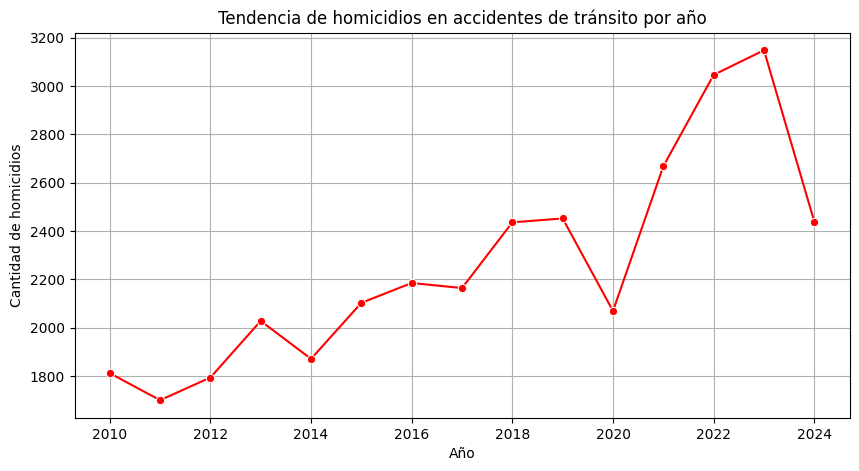

In [15]:
# Extraer el año
df_clean["AÑO"] = df_clean["FECHA HECHO"].dt.year

# Contar homicidios por año
homicidios_por_año = df_clean.groupby("AÑO")["CANTIDAD"].sum().reset_index()

# Graficar
plt.figure(figsize=(10, 5))
sns.lineplot(data=homicidios_por_año, x="AÑO", y="CANTIDAD", marker="o", color="red")
plt.title("Tendencia de homicidios en accidentes de tránsito por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de homicidios")
plt.grid(True)
plt.show()


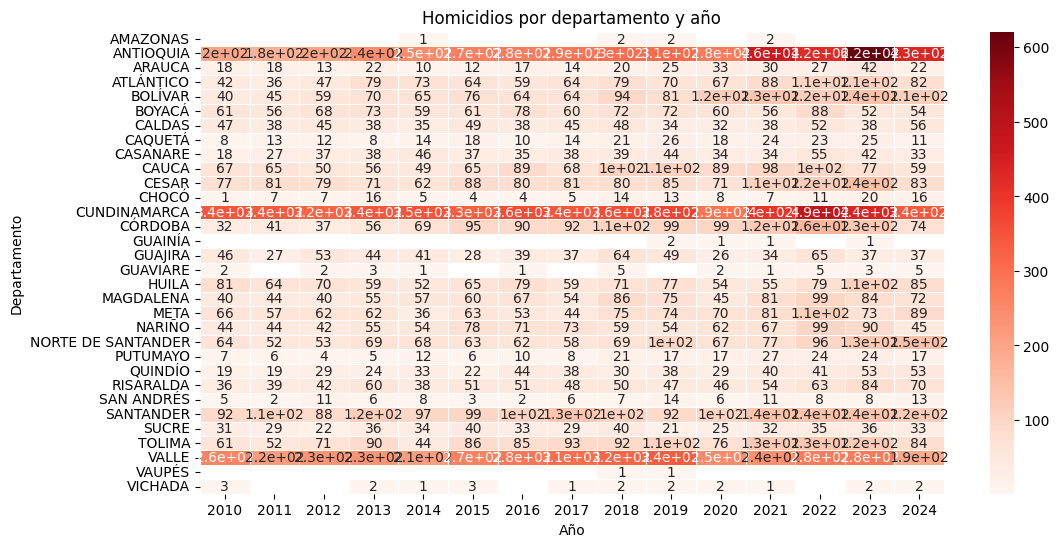

In [16]:
# Crear tabla pivot para el heatmap
heatmap_data = df_clean.pivot_table(values="CANTIDAD", index="DEPARTAMENTO", columns="AÑO", aggfunc="sum")

# Graficar heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="Reds", linewidths=0.5, annot=True)
plt.title("Homicidios por departamento y año")
plt.xlabel("Año")
plt.ylabel("Departamento")
plt.show()


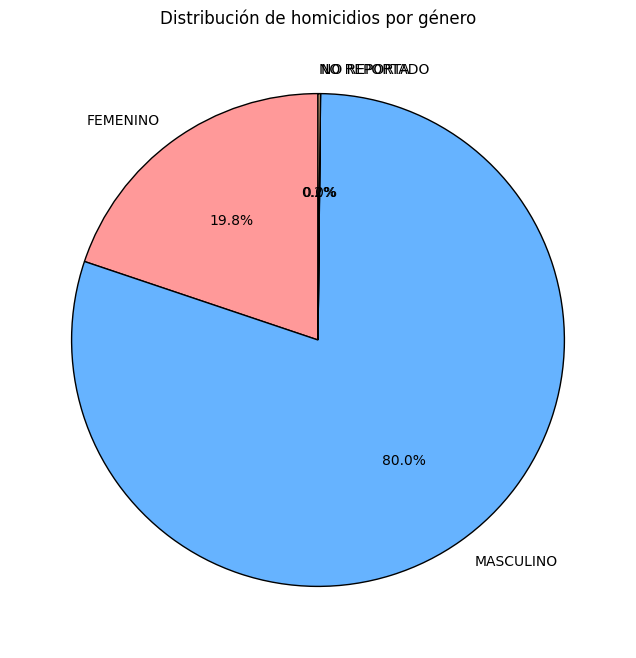

In [17]:
# Contar homicidios por género
genero_counts = df_clean.groupby("GENERO")["CANTIDAD"].sum()

# Colores personalizados
colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]

# Graficar
plt.figure(figsize=(8, 8))
plt.pie(genero_counts, labels=genero_counts.index, autopct="%1.1f%%", colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Distribución de homicidios por género")
plt.show()


<ipython-input-18-307746547091>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x="GRUPO ETARÍO", y="CANTIDAD", estimator=sum, palette="coolwarm", ci=None)
<ipython-input-18-307746547091>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="GRUPO ETARÍO", y="CANTIDAD", estimator=sum, palette="coolwarm", ci=None)


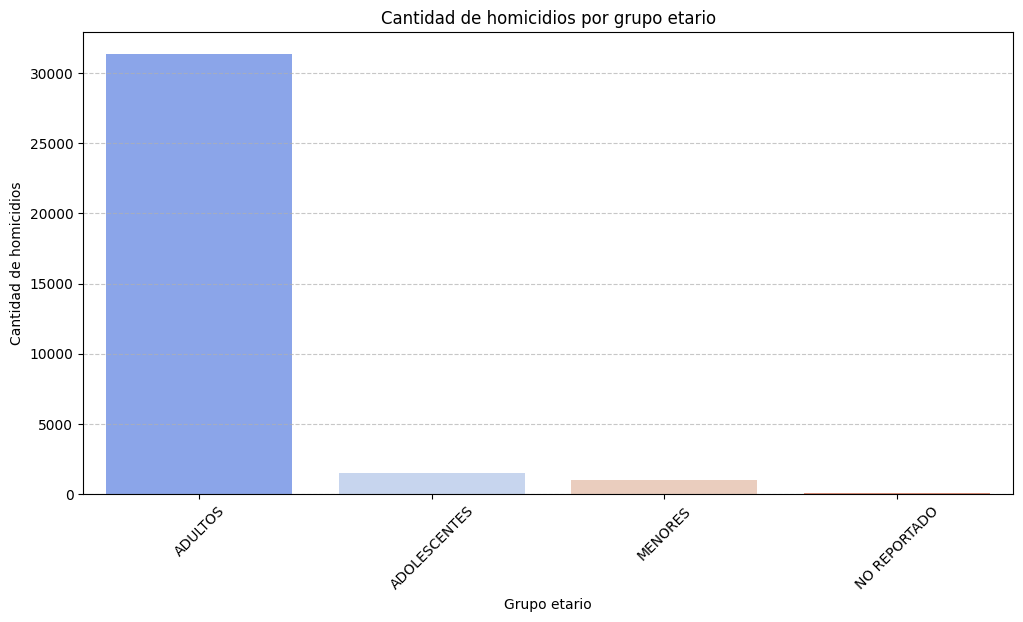

In [18]:
# Contar homicidios por grupo etario
plt.figure(figsize=(12, 6))
sns.barplot(data=df_clean, x="GRUPO ETARÍO", y="CANTIDAD", estimator=sum, palette="coolwarm", ci=None)
plt.title("Cantidad de homicidios por grupo etario")
plt.xlabel("Grupo etario")
plt.ylabel("Cantidad de homicidios")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


<ipython-input-19-da2b29733ef4>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, y="ARMAS MEDIOS", x="CANTIDAD", estimator=sum, palette="mako", ci=None)
<ipython-input-19-da2b29733ef4>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, y="ARMAS MEDIOS", x="CANTIDAD", estimator=sum, palette="mako", ci=None)


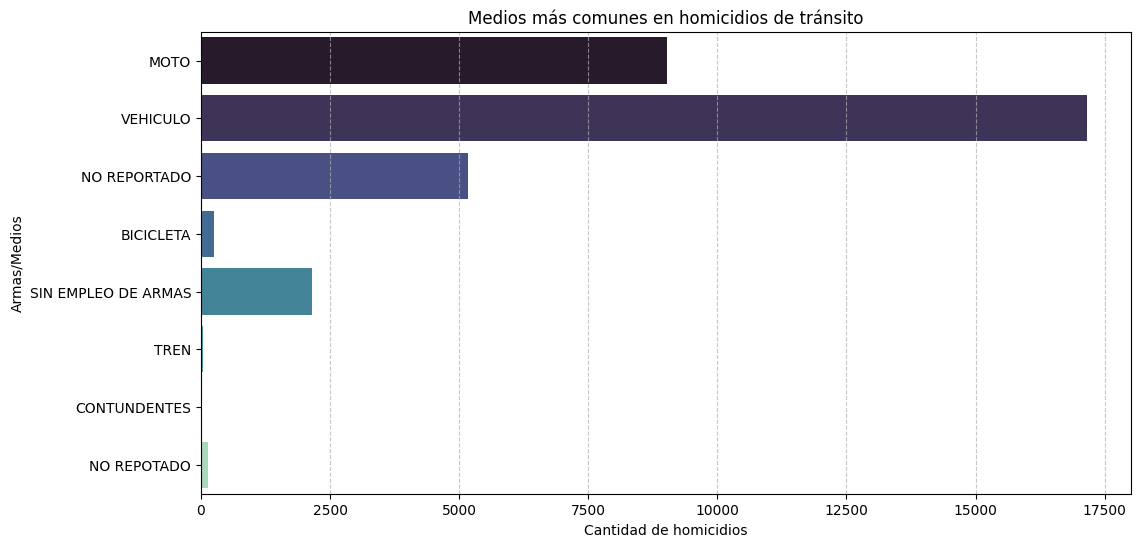

In [19]:
# Contar homicidios por armas/medios
plt.figure(figsize=(12, 6))
sns.barplot(data=df_clean, y="ARMAS MEDIOS", x="CANTIDAD", estimator=sum, palette="mako", ci=None)
plt.title("Medios más comunes en homicidios de tránsito")
plt.xlabel("Cantidad de homicidios")
plt.ylabel("Armas/Medios")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


<ipython-input-20-8ec596acab87>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_departamentos.values, y=top_departamentos.index, palette="viridis")


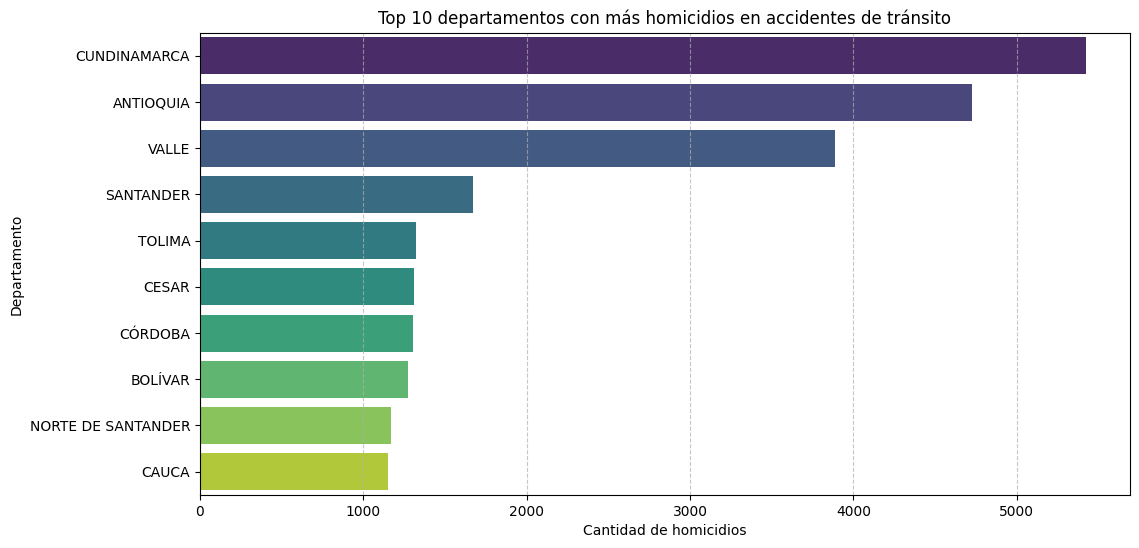

In [20]:
# Top 10 departamentos con más homicidios
top_departamentos = df_clean.groupby("DEPARTAMENTO")["CANTIDAD"].sum().nlargest(10)

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x=top_departamentos.values, y=top_departamentos.index, palette="viridis")
plt.title("Top 10 departamentos con más homicidios en accidentes de tránsito")
plt.xlabel("Cantidad de homicidios")
plt.ylabel("Departamento")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


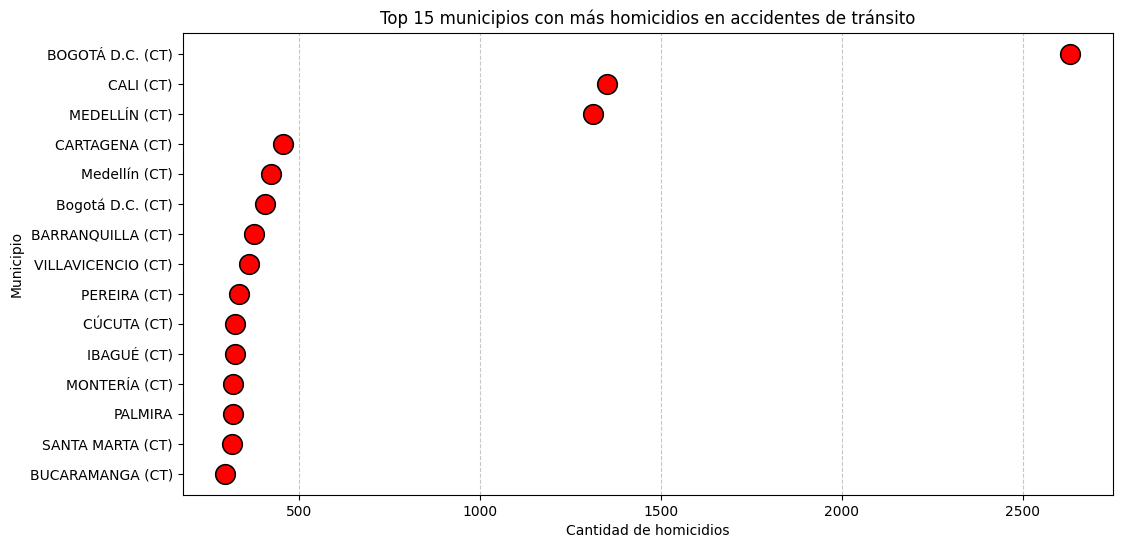

In [21]:
# Top 15 municipios con más homicidios
top_municipios = df_clean.groupby("MUNICIPIO")["CANTIDAD"].sum().nlargest(15)

# Graficar
plt.figure(figsize=(12, 6))
sns.scatterplot(x=top_municipios.values, y=top_municipios.index, s=200, color="red", edgecolor="black")
plt.title("Top 15 municipios con más homicidios en accidentes de tránsito")
plt.xlabel("Cantidad de homicidios")
plt.ylabel("Municipio")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


# 7. Predicción de homicidios en accidentes de tránsito

*   Vamos a usar un modelo de Machine Learning para predecir la cantidad de homicidios en función del tiempo. Usaremos Regresión Lineal de scikit-learn





In [22]:
# Convertimos la fecha en un número (AÑO) para la predicción
df_clean["AÑO"] = df_clean["FECHA HECHO"].dt.year

# Agrupamos por año para ver la tendencia general
df_pred = df_clean.groupby("AÑO")["CANTIDAD"].sum().reset_index()

# Variables de entrenamiento
X = df_pred[["AÑO"]]
y = df_pred["CANTIDAD"]

# Dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Evaluación del modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🔹 MAE (Error Absoluto Medio): {mae:.2f}")
print(f"🔹 MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"🔹 R² (Precisión del modelo): {r2:.2f}")


🔹 MAE (Error Absoluto Medio): 98.23
🔹 MSE (Error Cuadrático Medio): 13130.04
🔹 R² (Precisión del modelo): 0.90


In [24]:
# Predecimos para los próximos 5 años
años_futuros = np.array([[a] for a in range(df_pred["AÑO"].max() + 1, df_pred["AÑO"].max() + 6)])
predicciones_futuras = modelo.predict(años_futuros)

# Crear DataFrame con predicciones
df_futuro = pd.DataFrame({"AÑO": años_futuros.flatten(), "CANTIDAD PREDICHA": predicciones_futuras})

# Mostrar predicciones
print(df_futuro)


    AÑO  CANTIDAD PREDICHA
0  2025        2935.444093
1  2026        3022.205452
2  2027        3108.966812
3  2028        3195.728171
4  2029        3282.489530


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


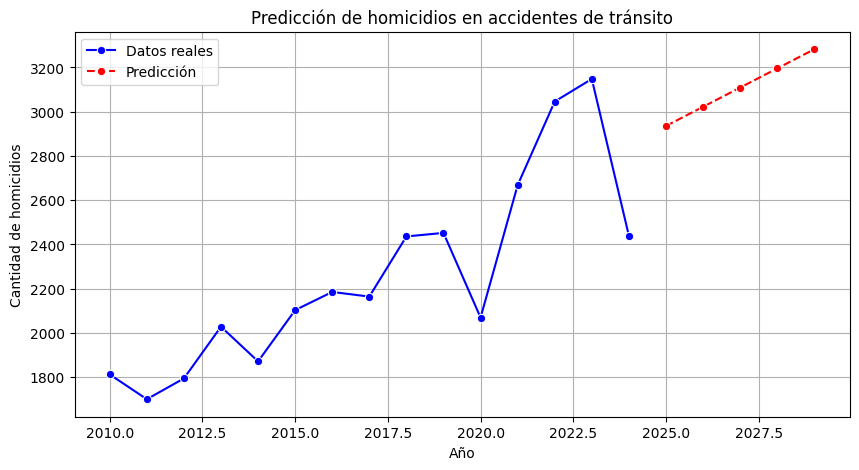

In [25]:
plt.figure(figsize=(10, 5))

# Graficar datos reales
sns.lineplot(data=df_pred, x="AÑO", y="CANTIDAD", marker="o", label="Datos reales", color="blue")

# Graficar predicciones futuras
sns.lineplot(data=df_futuro, x="AÑO", y="CANTIDAD PREDICHA", marker="o", label="Predicción", color="red", linestyle="dashed")

plt.title("Predicción de homicidios en accidentes de tránsito")
plt.xlabel("Año")
plt.ylabel("Cantidad de homicidios")
plt.legend()
plt.grid(True)
plt.show()
